In [1]:
import torch
from matplotlib import pyplot as plt
from torchvision.utils import make_grid
from diffusion.approaches.ddpm.ddpm_generator import DDPMGenerator
from diffusion.architectures.res_unet import ResUnet
from diffusion.data.mnist_sampleable import MNISTSampleable


In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

mps


In [3]:
sampeable = MNISTSampleable(train=True)

timesteps = 10

backbone = ResUnet(
    in_channels=1,
    channels=[16, 32, 64],
    num_classes=sampeable.num_classes,
    t_dim=64,
    y_dim=32,
    cond_dim=64,
).to(device)

backbone.load_state_dict(torch.load("./models/backbone_ddpm.pt"))

<All keys matched successfully>

10it [00:01,  8.28it/s]
10it [00:06,  1.59it/s]
10it [00:30,  3.07s/it]


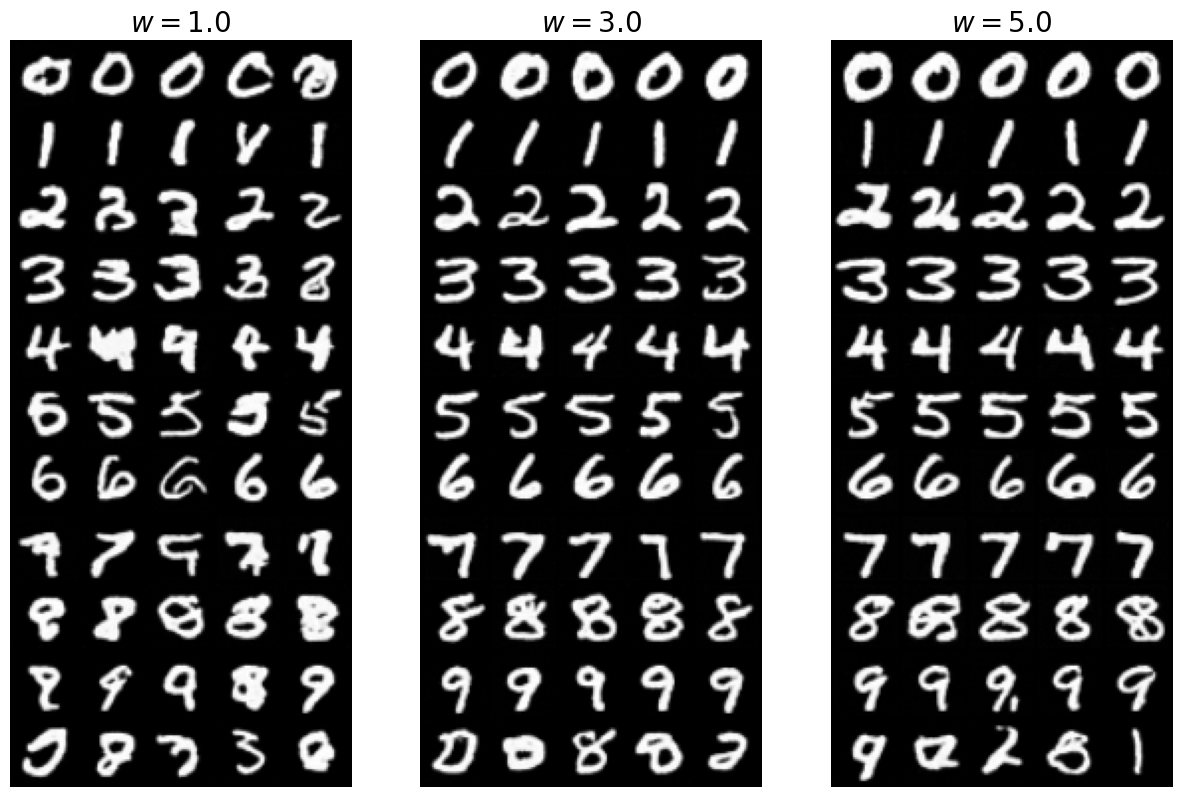

In [ ]:
samples_per_class = 5
guidance_scales = [1.0, 3.0, 5.0]

y = (
    torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
    .repeat_interleave(samples_per_class)
    .to(device)
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(guidance_scales),
    figsize=(samples_per_class * len(guidance_scales), 10),
)

ddpm_generator = DDPMGenerator(
    backbone=backbone,
    device=device,
    timesteps=timesteps,
    null_class=sampeable.num_classes,
    shape=sampeable.shape,
)

x0 = ddpm_generator.sample_prior(
    num_samples=y.shape[0], shape=sampeable.shape, device=device
)

for idx, w in enumerate(guidance_scales):
    x1 = ddpm_generator.generate(y=y, x0=x0, guidance_scale=w)

    grid = make_grid(x1, nrow=samples_per_class, normalize=True, value_range=(-1, 1))

    axes[idx].imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
    axes[idx].set_title(f"$w={w:.1f}$", fontsize=20)
    axes[idx].axis("off")

plt.show()